Time column is increasing: True
Missing values:
time    0
0_x     0
dtype: int64


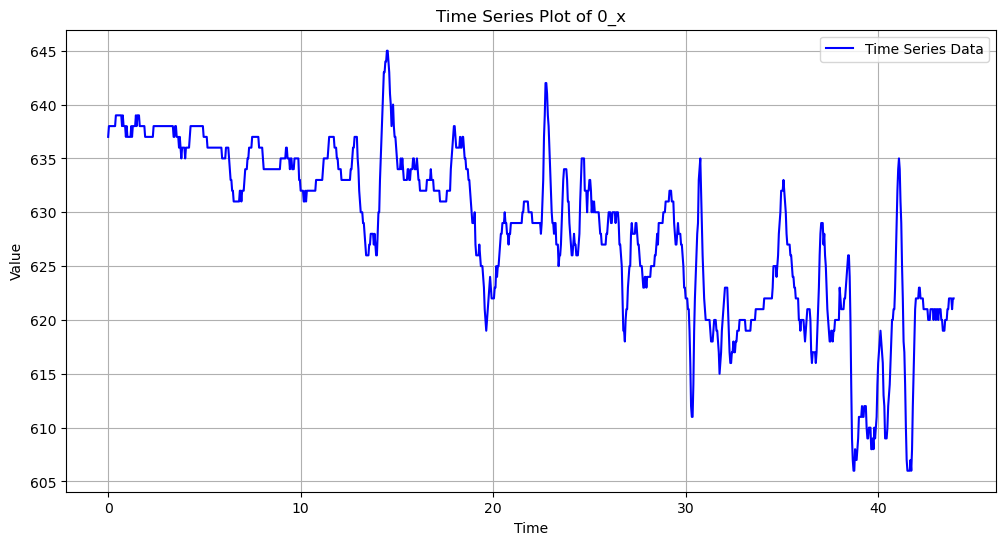

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")

# 2. Zaman Serisi Doğrulama
print("Time column is increasing:", df['time'].is_monotonic_increasing)
print("Missing values:")
print(df.isnull().sum())

# 3. Zaman Serisi Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['0_x'], label="Time Series Data", color="blue")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot of 0_x")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# 4. ADF Durağanlık Testi
adf_test = adfuller(df['0_x'])
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])
print("Critical Values:", adf_test[4])

# Durağan olup olmadığını kontrol etme
if adf_test[1] < 0.05:
    print("Sonuç: Seri durağandır (Stationary)")
else:
    print("Sonuç: Seri durağan değildir (Non-Stationary)")

ADF Statistic: -2.16454425286854
p-value: 0.2193645005987337
Critical Values: {'1%': -3.4364137337554785, '5%': -2.864217382986235, '10%': -2.568195530545688}
Sonuç: Seri durağan değildir (Non-Stationary)


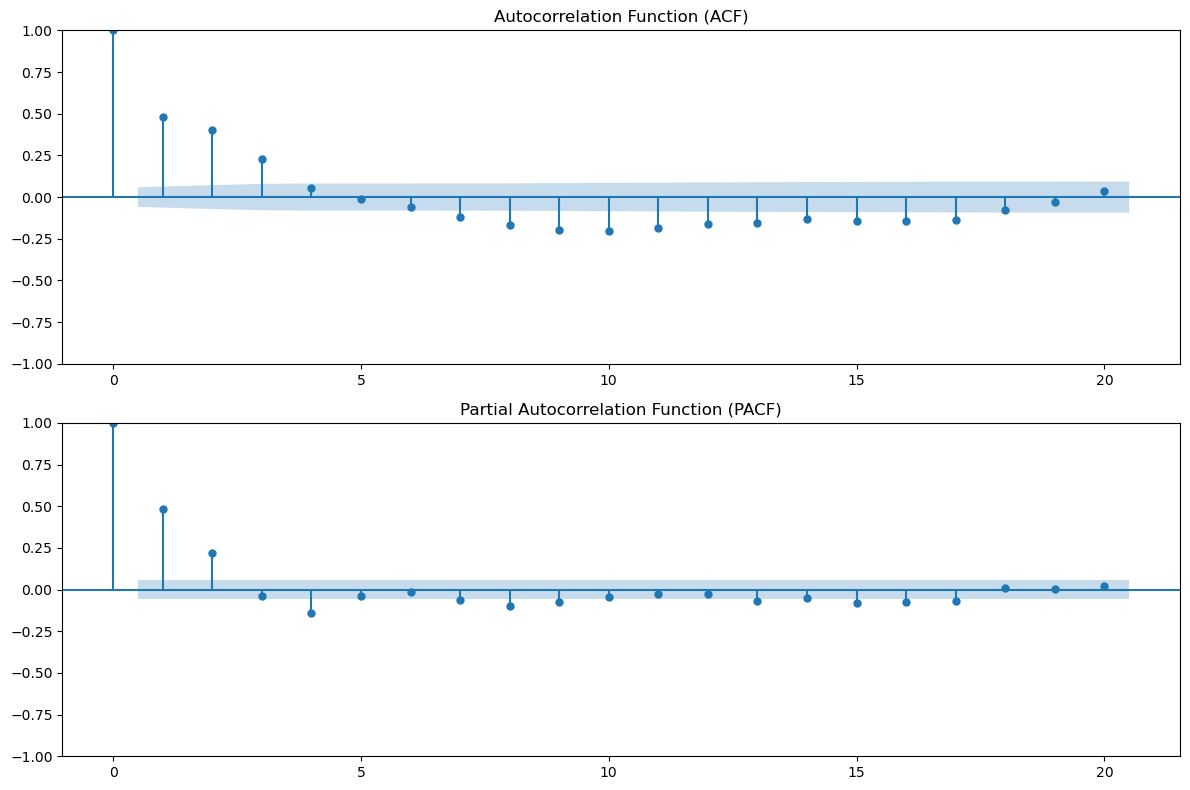

In [4]:
# 6. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['0_x'].dropna(), ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df['0_x'].dropna(), ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:                    0_x   No. Observations:                 1099
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -1505.103
Date:                Mon, 17 Mar 2025   AIC                           3014.206
Time:                        15:38:46   BIC                           3024.209
Sample:                             0   HQIC                          3017.991
                               - 1099                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3344      0.021     15.764      0.000       0.293       0.376
sigma2         0.9080      0.027     33.590      0.000       0.855       0.961
Ljung-Box (L1) (Q):                  12.24   Jarque-

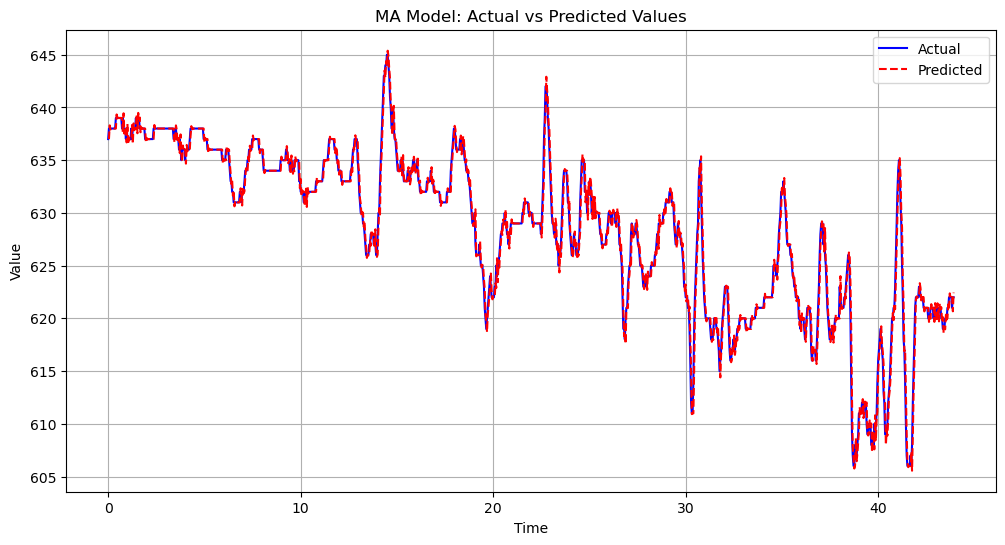

In [5]:
# 7. MA Modelini Uygulama
model = ARIMA(df['0_x'], order=(0, 1, 1))  # MA(1) modeli
model_fit = model.fit()
print(model_fit.summary())

# 8. Tahminlerin Görselleştirilmesi
df['predictions'] = model_fit.predict(start=1, end=len(df), dynamic=False)
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['0_x'], label="Actual", color="blue")
plt.plot(df['time'], df['predictions'], label="Predicted", linestyle="dashed", color="red")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("MA Model: Actual vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# 9. Performans Metriklerini Hesaplama
actual_values = df['0_x'][1:].values  # İlk fark alınan değer kaybolduğu için 1'den itibaren alıyoruz.
predicted_values = df['predictions'][1:].values

mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for i in range(len(actual_values)):
    print(f"Gerçek: {actual_values[i]}, Tahmin: {predicted_values[i]}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 638, Tahmin: 637.0001934171845
Gerçek: 638, Tahmin: 638.3007020780988
Gerçek: 638, Tahmin: 637.9005663325854
Gerçek: 638, Tahmin: 638.0332083594254
Gerçek: 638, Tahmin: 637.9888969889718
Gerçek: 638, Tahmin: 638.0037126814136
Gerçek: 638, Tahmin: 637.9987585175481
Gerçek: 638, Tahmin: 638.000415139594
Gerçek: 638, Tahmin: 637.9998611813546
Gerçek: 639, Tahmin: 638.0000464196067
Gerçek: 639, Tahmin: 639.3343747656064
Gerçek: 639, Tahmin: 638.8881883259523
Gerçek: 639, Tahmin: 639.0373887378722
Gerçek: 639, Tahmin: 638.9874975691797
Gerçek: 639, Tahmin: 639.0041806914411
Gerçek: 639, Tahmin: 638.9986020173856
Gerçek: 639, Tahmin: 639.0004674718089
Gerçek: 638, Tahmin: 638.9998436819673
Gerçek: 639, Tahmin: 637.6656619833599
Gerçek: 638, Tahmin: 639.4461896735029
Gerçek: 638, Tahmin: 637.5164082187598
Gerçek: 638, Tahmin: 638.1617083949415
Gerçek: 637, Tahmin: 637.9459262832642
Gerçek: 638, Tahmin: 636.6836914378335
Gerçek: 637, Tahmin: 6